
=== ROBUSTEZ POR ALGORITMO (ordenado) ===

Mean (μ):
            hypervolume_feas  hypervolume_norm   f1_norm  f2_norm  n_gen_real
algorithm                                                                   
moead             58.773228          0.622385  0.374232     0.00        29.4
smsemoa           73.311920          0.954869  0.064487     0.44        50.7

Std (σ):
            hypervolume_feas  hypervolume_norm   f1_norm   f2_norm  n_gen_real
algorithm                                                                    
moead             10.961343          0.250674  0.265780  0.000000   13.023056
smsemoa            0.631100          0.014433  0.022509  0.084327    0.948683

CV (σ/μ):
            hypervolume_feas  hypervolume_norm   f1_norm   f2_norm  n_gen_real
algorithm                                                                    
moead              0.186502          0.402763  0.710202       NaN    0.442961
smsemoa            0.008608          0.015115  0.349046  0.191653   

<Figure size 720x432 with 0 Axes>

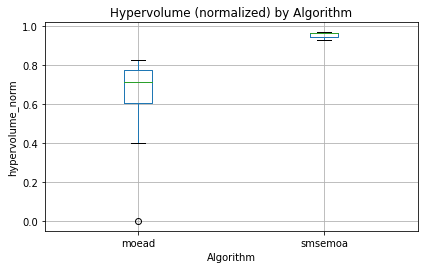

✔ Saved: figures/hv_norm_by_algorithm_boxplot.pdf


<Figure size 720x432 with 0 Axes>

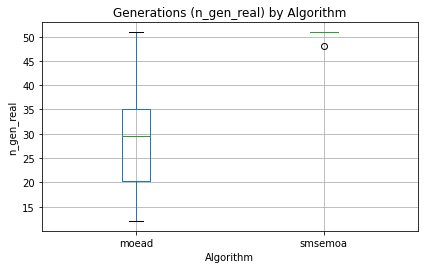

✔ Saved: figures/n_gen_real_by_algorithm_boxplot.pdf


<Figure size 720x432 with 0 Axes>

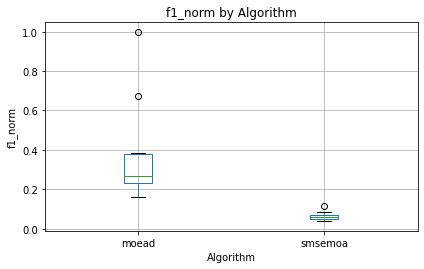

✔ Saved: figures/f1_norm_by_algorithm_boxplot.pdf


<Figure size 720x432 with 0 Axes>

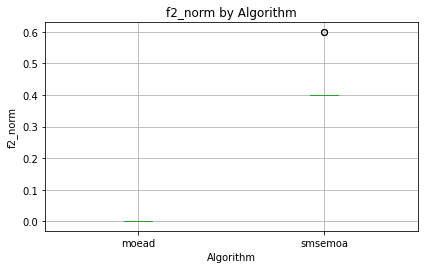

✔ Saved: figures/f2_norm_by_algorithm_boxplot.pdf


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# =========================
# CARGA
# =========================
base_dir = Path("results")
alg_dirs = ["MOEAD", "NSGA2", "SMSEMOA"]
csv_paths = [base_dir / alg / "runs_summary.csv" for alg in alg_dirs]

dfs = []
for path in csv_paths:
    if not path.exists():
        raise FileNotFoundError(f"No existe: {path}")
    df = pd.read_csv(path)
    df["_source_csv"] = str(path)
    dfs.append(df)

metrics_df = pd.concat(dfs, ignore_index=True)

# Asegura tipos
metrics_df["algorithm"] = metrics_df["algorithm"].astype(str)

# =========================
# ROBUSTEZ (CV) POR ALGORITMO
# =========================
group_col = "algorithm"

# Métricas a evaluar (ajusta si quieres)
metric_cols = [
    "hypervolume_feas",
    "hypervolume_norm",
    "f1_norm",
    "f2_norm",
    "n_gen_real",
]

# Validación rápida de columnas
missing = [c for c in [group_col] + metric_cols if c not in metrics_df.columns]
if missing:
    raise ValueError(f"Faltan columnas en el CSV: {missing}")

subset_df = metrics_df[[group_col] + metric_cols].copy()


for col in metric_cols:
    subset_df[col] = pd.to_numeric(subset_df[col], errors='coerce')

grouped = subset_df.groupby(group_col)

# 3. Calculamos la media y la desviación estándar sin el argumento 'numeric_only'
mean_metrics = grouped.mean()
std_metrics  = grouped.std()

# CV robusto: evita divisiones por cero (si mean==0 -> NaN)
cv_metrics = std_metrics.divide(mean_metrics.replace(0, np.nan))

def classify_robustness(cv_value):
    if pd.isna(cv_value) or np.isinf(cv_value):
        return "Undefined"
    elif cv_value < 0.05:
        return "High Robustness"
    elif 0.05 <= cv_value <= 0.10:
        return "Acceptable Robustness"
    else:
        return "Low Robustness"

robustness_levels = cv_metrics.apply(lambda col: col.map(classify_robustness))

# Orden: usa el orden de carpetas (MOEAD, NSGA2, SMSEMOA) si existe en el índice
order = [a.lower() for a in alg_dirs]  # en tus datos parece venir "smsemoa", etc.
valid_order = [a for a in order if a in mean_metrics.index]
# Si no coincide por mayúsculas/minúsculas, prueba el índice real:
if not valid_order:
    # fallback: orden alfabético del índice
    valid_order = list(mean_metrics.index)

mean_metrics = mean_metrics.loc[valid_order]
std_metrics  = std_metrics.loc[valid_order]
cv_metrics   = cv_metrics.loc[valid_order]
robustness_levels = robustness_levels.loc[valid_order]

print("\n=== ROBUSTEZ POR ALGORITMO (ordenado) ===")
print("\nMean (μ):\n", mean_metrics)
print("\nStd (σ):\n", std_metrics)
print("\nCV (σ/μ):\n", cv_metrics)
print("\nRobustness Levels:\n", robustness_levels)

# =========================
# BOXPLOTS POR ALGORITMO
# =========================
fig_dir = Path("./figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# Asegura el orden en plots
metrics_df[group_col] = pd.Categorical(
    metrics_df[group_col],
    categories=valid_order,
    ordered=True
)
metrics_df_sorted = metrics_df.sort_values(group_col)

# 1) Hypervolume_norm
plt.figure(figsize=(10, 6))
metrics_df_sorted.boxplot(column=["hypervolume_norm"], by=group_col, grid=True, vert=True)
plt.title("Hypervolume (normalized) by Algorithm")
plt.suptitle("")
plt.xlabel("Algorithm")
plt.ylabel("hypervolume_norm")
plt.tight_layout()
out1 = fig_dir / "hv_norm_by_algorithm_boxplot.pdf"
plt.savefig(out1, format="pdf")
plt.show()
print("✔ Saved:", out1)

# 2) n_gen_real
plt.figure(figsize=(10, 6))
metrics_df_sorted.boxplot(column=["n_gen_real"], by=group_col, grid=True, vert=True)
plt.title("Generations (n_gen_real) by Algorithm")
plt.suptitle("")
plt.xlabel("Algorithm")
plt.ylabel("n_gen_real")
plt.tight_layout()
out2 = fig_dir / "n_gen_real_by_algorithm_boxplot.pdf"
plt.savefig(out2, format="pdf")
plt.show()
print("✔ Saved:", out2)

# (Opcional) f1_norm y f2_norm
plt.figure(figsize=(10, 6))
metrics_df_sorted.boxplot(column=["f1_norm"], by=group_col, grid=True, vert=True)
plt.title("f1_norm by Algorithm")
plt.suptitle("")
plt.xlabel("Algorithm")
plt.ylabel("f1_norm")
plt.tight_layout()
out3 = fig_dir / "f1_norm_by_algorithm_boxplot.pdf"
plt.savefig(out3, format="pdf")
plt.show()
print("✔ Saved:", out3)

plt.figure(figsize=(10, 6))
metrics_df_sorted.boxplot(column=["f2_norm"], by=group_col, grid=True, vert=True)
plt.title("f2_norm by Algorithm")
plt.suptitle("")
plt.xlabel("Algorithm")
plt.ylabel("f2_norm")
plt.tight_layout()
out4 = fig_dir / "f2_norm_by_algorithm_boxplot.pdf"
plt.savefig(out4, format="pdf")
plt.show()
print("✔ Saved:", out4)


In [3]:
import pandas as pd
import numpy as np
from pathlib import Path

# Ruta a tu history (ajusta si está en otra carpeta)
history_path = Path("results/NSGA2/history.csv")

history_df = pd.read_csv(history_path)

# Asegurar tipos
history_df["experiment_id"] = history_df["experiment_id"].astype(str)

# Extraer algoritmo desde experiment_id
history_df["algorithm"] = history_df["experiment_id"].str.split("_").str[0]

# Métricas que quieres evaluar
metric_cols = [
    "hypervolume_feas",
    "f1_min_feas",
    "f2_min_feas"
]

# Agrupar por ejecución
grouped = history_df.groupby("experiment_id")

mean_metrics = grouped[metric_cols].mean()
std_metrics  = grouped[metric_cols].std()

# CV (evitando división por 0)
cv_metrics = std_metrics.divide(mean_metrics.replace(0, np.nan))

# Clasificación
def classify_robustness(cv):
    if pd.isna(cv) or np.isinf(cv):
        return "Undefined"
    if cv < 0.05:
        return "High Robustness"
    if cv <= 0.10:
        return "Acceptable Robustness"
    return "Low Robustness"

robustness_levels = cv_metrics.apply(lambda col: col.map(classify_robustness))

# Añadir algoritmo a resultados
cv_metrics["algorithm"] = cv_metrics.index.str.split("_").str[0]
robustness_levels["algorithm"] = robustness_levels.index.str.split("_").str[0]

print("=== CV temporal por ejecución ===")
print(cv_metrics)

print("\n=== Clasificación de robustez por ejecución ===")
print(robustness_levels)


=== CV temporal por ejecución ===
                            hypervolume_feas  f1_min_feas  f2_min_feas  \
experiment_id                                                            
NSGA2_sbx_polynomial_run01          0.038023    -0.008635     0.000000   
NSGA2_sbx_polynomial_run02          0.069121    -0.010225     0.405179   
NSGA2_sbx_polynomial_run03          0.018045    -0.009054     0.116455   
NSGA2_sbx_polynomial_run04          0.037482    -0.009249     0.339283   
NSGA2_sbx_polynomial_run05          0.057182    -0.021698     0.561480   
NSGA2_sbx_polynomial_run06          0.025550    -0.010233     0.259740   
NSGA2_sbx_polynomial_run07          0.022942    -0.019349     0.281223   
NSGA2_sbx_polynomial_run08          0.026463    -0.008886     0.450589   
NSGA2_sbx_polynomial_run09          0.025334    -0.004397     0.400249   
NSGA2_sbx_polynomial_run10          0.064585    -0.013596     0.456348   

                           algorithm  
experiment_id                         

In [4]:
cv_metrics


,hypervolume_feas,f1_min_feas,f2_min_feas,algorithm
experiment_id,,,,
NSGA2_sbx_polynomial_run01,0.038023,-0.008635,0.000000,NSGA2
NSGA2_sbx_polynomial_run02,0.069121,-0.010225,0.405179,NSGA2
NSGA2_sbx_polynomial_run03,0.018045,-0.009054,0.116455,NSGA2
NSGA2_sbx_polynomial_run04,0.037482,-0.009249,0.339283,NSGA2
NSGA2_sbx_polynomial_run05,0.057182,-0.021698,0.561480,NSGA2
NSGA2_sbx_polynomial_run06,0.025550,-0.010233,0.259740,NSGA2
NSGA2_sbx_polynomial_run07,0.022942,-0.019349,0.281223,NSGA2
NSGA2_sbx_polynomial_run08,0.026463,-0.008886,0.450589,NSGA2
NSGA2_sbx_polynomial_run09,0.025334,-0.004397,0.400249,NSGA2


<Figure size 720x432 with 0 Axes>

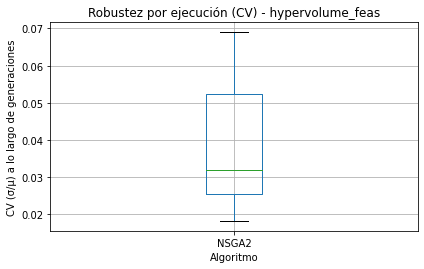

✔ Saved: figures/cv_hypervolume_feas_by_algorithm_boxplot.pdf


<Figure size 720x432 with 0 Axes>

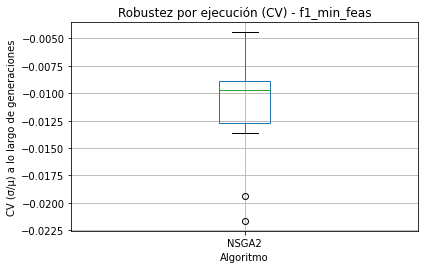

✔ Saved: figures/cv_f1_min_feas_by_algorithm_boxplot.pdf


<Figure size 720x432 with 0 Axes>

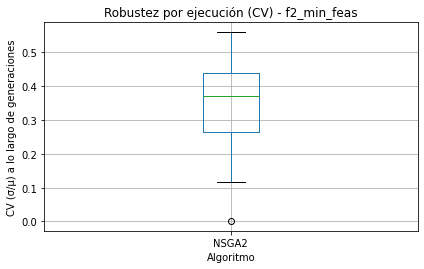

✔ Saved: figures/cv_f2_min_feas_by_algorithm_boxplot.pdf


In [5]:
import matplotlib.pyplot as plt
from pathlib import Path

# --- Asegurar columna algoritmo (en tu df parece llamarse 'algorithmm')
algo_col = "algorithmm" if "algorithmm" in cv_metrics.columns else "algorithm"

# --- Métricas CV que quieres plotear
metrics_to_plot = ["hypervolume_feas", "f1_min_feas", "f2_min_feas"]

# --- (Opcional) crear carpeta de salida
fig_dir = Path("./figures")
fig_dir.mkdir(parents=True, exist_ok=True)

# --- Convertir a categórico (para ordenar siempre igual)
order = ["MOEAD", "NSGA2", "SMSEMOA"]
valid_order = [a for a in order if a in cv_metrics[algo_col].unique()]
if valid_order:
    cv_metrics[algo_col] = cv_metrics[algo_col].astype(str)
    cv_metrics[algo_col] = cv_metrics[algo_col].astype("category")
    cv_metrics[algo_col] = cv_metrics[algo_col].cat.set_categories(valid_order, ordered=True)

for m in metrics_to_plot:
    plt.figure(figsize=(10, 6))
    cv_metrics.boxplot(column=m, by=algo_col, grid=True, vert=True)
    plt.title(f"Robustez por ejecución (CV) - {m}")
    plt.suptitle("")
    plt.xlabel("Algoritmo")
    plt.ylabel("CV (σ/μ) a lo largo de generaciones")
    plt.xticks(rotation=0)
    plt.tight_layout()

    out = fig_dir / f"cv_{m}_by_algorithm_boxplot.pdf"
    plt.savefig(out, format="pdf")
    plt.show()
    print("✔ Saved:", out)


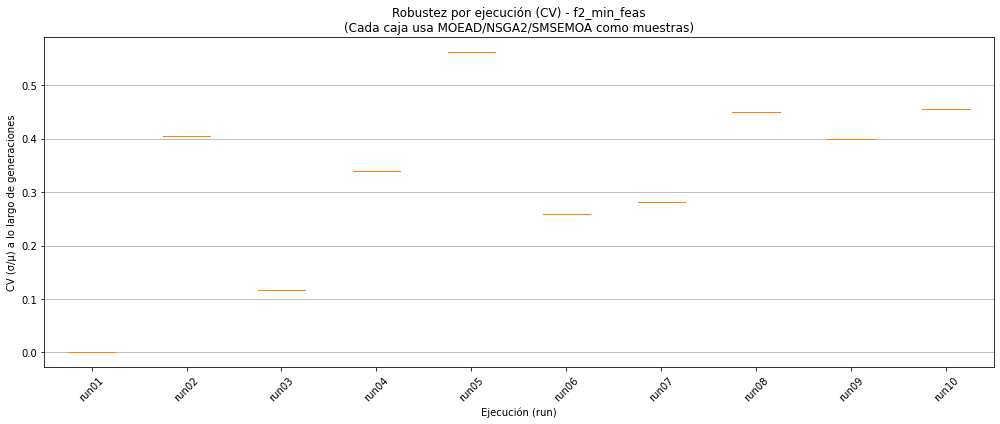

✔ Saved: figures/cv_f2_min_feas_boxplot_by_run.pdf


In [6]:
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

metric = "f2_min_feas"  # o "hypervolume_feas" o "f1_min_feas"

# Asegura experiment_id como columna
df = cv_metrics.copy()
df = df.reset_index() if "experiment_id" not in df.columns else df

# Extraer número de run: run01 -> 1
df["run_num"] = pd.to_numeric(
    df["experiment_id"].astype(str).str.split("run").str[-1],
    errors="coerce"
)

df = df.dropna(subset=["run_num", metric])
df["run_num"] = df["run_num"].astype(int)

# Etiqueta bonita run01..run10
df["run_tag"] = df["run_num"].apply(lambda x: f"run{int(x):02d}")

# Orden de runs (1..10)
order = [f"run{i:02d}" for i in range(1, 11)]
present = [r for r in order if r in df["run_tag"].unique()]

# Crear lista de arrays: valores (CV) por run
data = [df.loc[df["run_tag"] == r, metric].values for r in present]

plt.figure(figsize=(14, 6))
plt.boxplot(data, labels=present, showfliers=True)
plt.title(f"Robustez por ejecución (CV) - {metric}\n(Cada caja usa MOEAD/NSGA2/SMSEMOA como muestras)")
plt.xlabel("Ejecución (run)")
plt.ylabel("CV (σ/μ) a lo largo de generaciones")
plt.grid(True, axis="y")
plt.xticks(rotation=45)
plt.tight_layout()

fig_dir = Path("./figures")
fig_dir.mkdir(parents=True, exist_ok=True)
out = fig_dir / f"cv_{metric}_boxplot_by_run.pdf"
plt.savefig(out, format="pdf")
plt.show()
print("✔ Saved:", out)


In [7]:
print(cv_metrics.shape)
print(cv_metrics.head())


(10, 4)
                            hypervolume_feas  f1_min_feas  f2_min_feas  \
experiment_id                                                            
NSGA2_sbx_polynomial_run01          0.038023    -0.008635     0.000000   
NSGA2_sbx_polynomial_run02          0.069121    -0.010225     0.405179   
NSGA2_sbx_polynomial_run03          0.018045    -0.009054     0.116455   
NSGA2_sbx_polynomial_run04          0.037482    -0.009249     0.339283   
NSGA2_sbx_polynomial_run05          0.057182    -0.021698     0.561480   

                           algorithm  
experiment_id                         
NSGA2_sbx_polynomial_run01     NSGA2  
NSGA2_sbx_polynomial_run02     NSGA2  
NSGA2_sbx_polynomial_run03     NSGA2  
NSGA2_sbx_polynomial_run04     NSGA2  
NSGA2_sbx_polynomial_run05     NSGA2  


In [8]:
print(cv_metrics.columns)


Index(['hypervolume_feas', 'f1_min_feas', 'f2_min_feas', 'algorithm'], dtype='object')


=== ANÁLISIS DE ROBUSTEZ: NSGA-II (10 Runs) ===
Media (Calidad promedio): 73.7192
Mediana:                  73.5866
------------------------------
Desviación Estándar (Std): 0.8027  <-- DATO CLAVE
Coeficiente de Variación:  1.09%
Rango (Max - Min):         3.0114
Peor ejecución:            72.2740
Mejor ejecución:           75.2854


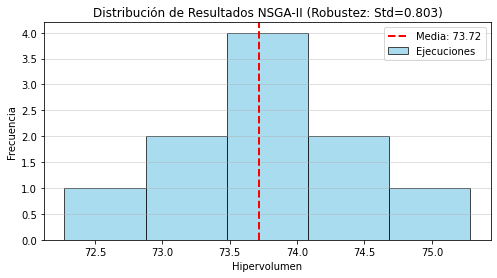

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# Ruta al archivo de resumen de NSGA-II
file_path = "results/NSGA2/runs_summary.csv"

# Verificamos si existe
if os.path.exists(file_path):
    df = pd.read_csv(file_path)
    
    # Extraemos la columna de Hipervolumen (asegúrate de que se llame así en tu CSV)
    datos = df["hypervolume_feas"]
    
    # --- CÁLCULO DE MÉTRICAS DE ROBUSTEZ ---
    media = datos.mean()
    mediana = datos.median()
    desv_std = datos.std()  # <--- ESTO ES LA ROBUSTEZ
    minimo = datos.min()
    maximo = datos.max()
    rango = maximo - minimo
    
    # Coeficiente de Variación (CV): Dice qué % varía respecto a la media
    # Si es < 5%, es MUY robusto. Si es > 20%, es inestable.
    cv = (desv_std / media) * 100 
    
    print("=== ANÁLISIS DE ROBUSTEZ: NSGA-II (10 Runs) ===")
    print(f"Media (Calidad promedio): {media:.4f}")
    print(f"Mediana:                  {mediana:.4f}")
    print("-" * 30)
    print(f"Desviación Estándar (Std): {desv_std:.4f}  <-- DATO CLAVE")
    print(f"Coeficiente de Variación:  {cv:.2f}%")
    print(f"Rango (Max - Min):         {rango:.4f}")
    print(f"Peor ejecución:            {minimo:.4f}")
    print(f"Mejor ejecución:           {maximo:.4f}")
    
    # --- GRÁFICO DE DISPERSIÓN ---
    plt.figure(figsize=(8, 4))
    
    # Histograma con curva de densidad
    plt.hist(datos, bins=5, alpha=0.7, color='skyblue', edgecolor='black', label='Ejecuciones')
    plt.axvline(media, color='red', linestyle='dashed', linewidth=2, label=f'Media: {media:.2f}')
    
    plt.title(f"Distribución de Resultados NSGA-II (Robustez: Std={desv_std:.3f})")
    plt.xlabel("Hipervolumen")
    plt.ylabel("Frecuencia")
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

else:
    print(f"Error: No encuentro el archivo en {file_path}")

In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

algoritmos = ["NSGA2", "SMSEMOA", "MOEAD"]

# Definimos las escalas de color (Monocromáticas)
mapa_colores = {
    "nsga2":   "Blues",   # Escala de Azules (Run 1 clara -> Run 10 oscura)
    "smsemoa": "Greens",  # Escala de Verdes
    "moead":   "Reds"     # Escala de Rojos
}

for a in algoritmos:
    file_path = f'results/{a}/history.csv'
    
    # Comprobación de seguridad
    if not os.path.exists(file_path):
        print(f"⚠️ Saltando {a}: No encuentro el archivo en {file_path}")
        continue

    # 1. Cargar el archivo
    df = pd.read_csv(file_path)

    # 2. Configurar el gráfico
    plt.figure(figsize=(12, 6))

    paleta_actual = mapa_colores.get(a, "Greys")

    # --- CORRECCIÓN DEL WARNING AQUÍ ---
    # Añadimos hue='run_id' y legend=False
# Guardamos el gráfico en una variable 'ax'
    ax = sns.boxplot(
        data=df,
        x='run_id',
        # ... (asegúrate de mantener tu variable 'y' aquí)
        hue='run_id' 
    )
    
    # Ocultamos la leyenda manualmente para evitar el error de versión
    if ax.legend_ is not None:
        ax.legend_.remove()

    # Puntos negros para ver densidad
    sns.stripplot(data=df, x='run_id', y='hypervolume_feas', color='#333333', alpha=0.3, size=3)

    plt.title(f'Distribución del Hipervolumen: {a.upper()}', fontsize=14)
    plt.xlabel('Ejecución (Run ID)', fontsize=12)
    plt.ylabel('Hipervolumen', fontsize=12)
    plt.grid(True, axis='y', linestyle='--', alpha=0.5)

    plt.tight_layout()

    # 3. Guardado
    folder_path = "figures/robustness"
    os.makedirs(folder_path, exist_ok=True)
    
    file_name = f"{a}.pdf"
    full_path = os.path.join(folder_path, file_name)

    plt.savefig(full_path)
    plt.close() # Cierra la figura para liberar memoria
    
    print(f"✅ Gráfico guardado sin errores: {full_path}")

✅ Gráfico guardado sin errores: figures/robustness/NSGA2.pdf
✅ Gráfico guardado sin errores: figures/robustness/SMSEMOA.pdf
✅ Gráfico guardado sin errores: figures/robustness/MOEAD.pdf
